In [1]:
import pandas as pd
import numpy as np
from aggregation import get_aggregate_interpolators, METHODS
import matplotlib.pyplot as plt

(0, 1.7689131235054247) (0, 63.90466892973979)
(0, 1.7689131235054247) (0, 63.90466892973979)
(0, 1.7689131235054247) (0, 63.90466892973979)
(0, 1.7689131235054247) (0, 63.90466892973979)
(0, 1.7689131235054247) (0, 63.90466892973979)
[5.156384411604959, 4.288185789424023, 3.640949186209726, 3.012156759718256, 2.4631462667082613, 1.974426561026358, 1.533557366705814, 1.1065910671865218, 0.6871180307349363, 0.486726449833025, 0.3336541514205394, 0.1612494780949106, 0.08784999394263347, 0.034612416237141695, 0.0]
[0.9105214124870201, 3.72703970629453, 6.560926316104246, 9.397619284209405, 12.230319529969806, 15.031549791414278, 17.862753126469322, 20.7102559220264, 23.52110723227803, 26.320150157674448, 29.18003103970582, 32.001834767072374, 34.81240026277276, 37.649480947730666, 40.47939839896063]
(0, 1.7689131235054247) (0, 63.90466892973979)


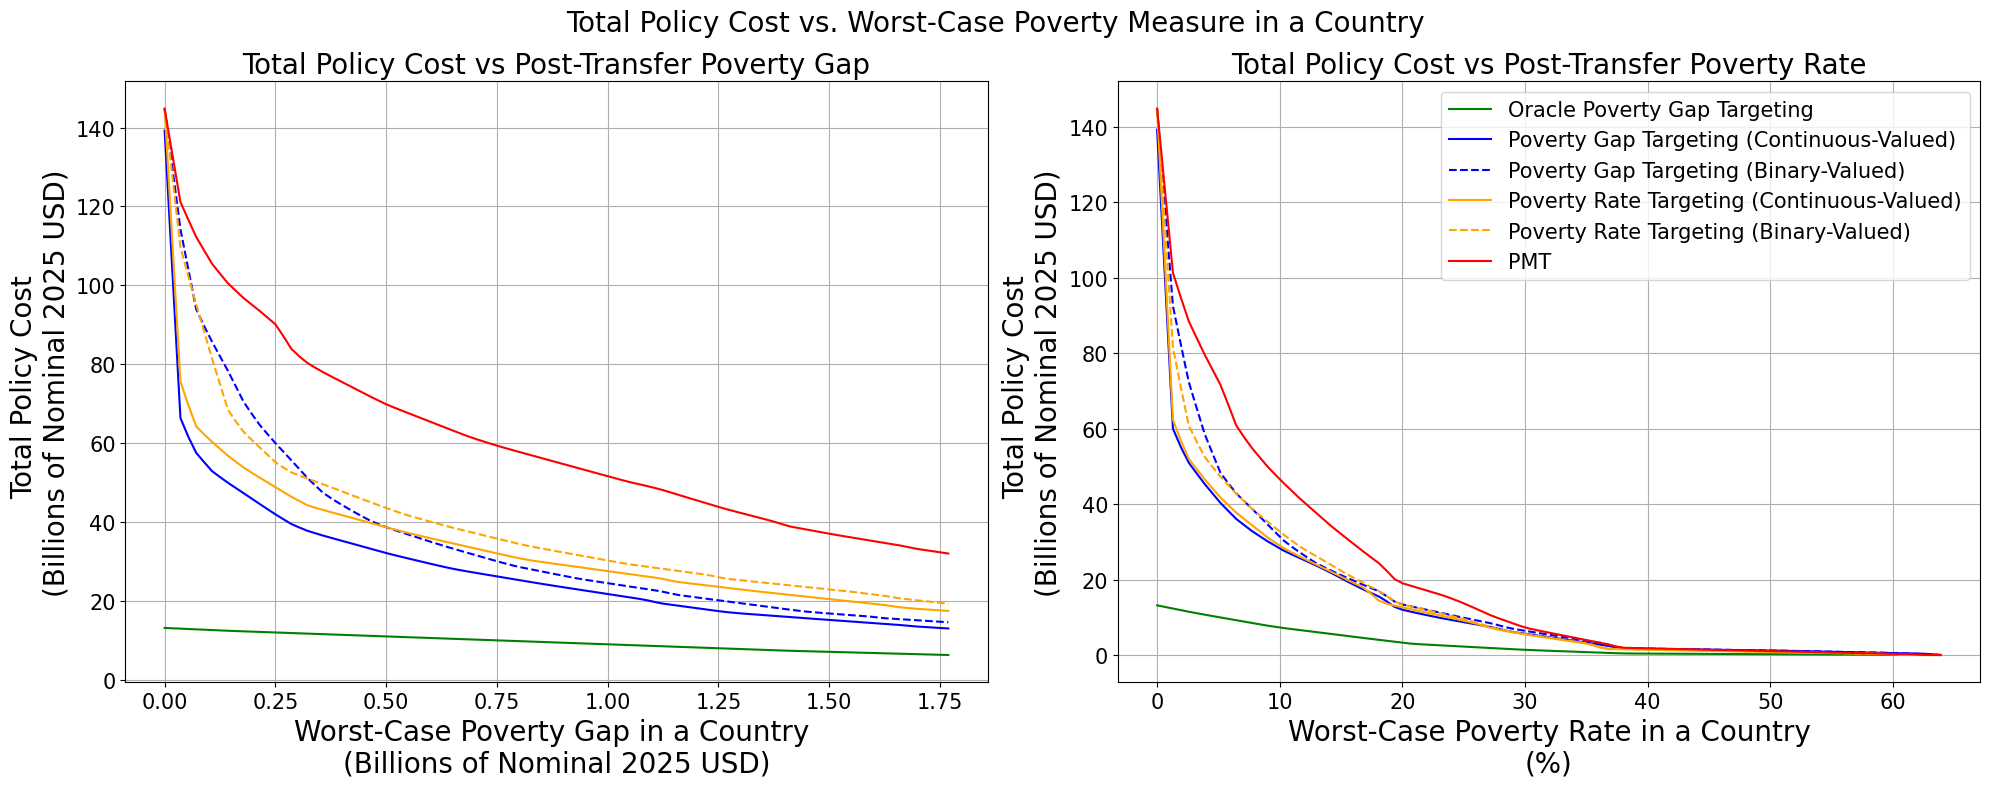

In [ ]:
COUNTRIES = ['nigeria', 'ethiopia','uganda','togo','malawi']

# Plot policy_cost_per_capita vs post_transfer_poverty_rate
fig, ax = plt.subplots(1, 2, figsize=(20, 8))
fontsize=20
for method in METHODS:
    dic = get_aggregate_interpolators(countries=COUNTRIES, method=method)
    gap_range = dic['gap']['range']
    gap_interpolator = dic['gap']['interpolator']
    rate_range = dic['rate']['range']
    rate_interpolator = dic['rate']['interpolator']
    print(gap_range, rate_range)

    ax[0].plot(np.linspace(gap_range[0], gap_range[1], 100), 
               gap_interpolator(np.linspace(gap_range[0], gap_range[1], 100)),
                 label=METHODS[method]["name"],
                 color=METHODS[method]["color"], 
                 linestyle=METHODS[method]["linestyle"])
    ax[1].plot(np.linspace(rate_range[0], rate_range[1], 100),
                rate_interpolator(np.linspace(rate_range[0], rate_range[1], 100)), 
                label=METHODS[method]["name"], color=METHODS[method]["color"],
                linestyle=METHODS[method]["linestyle"])
    
    ax[1].set_xlabel('Worst-Case Poverty Rate in a Country\n(%)', fontsize=fontsize)
    ax[0].set_xlabel('Worst-Case Poverty Gap in a Country \n(Billions of Nominal 2025 USD)', fontsize=fontsize)
    ax[1].set_title('Total Policy Cost vs Post-Transfer Poverty Rate', fontsize=fontsize)
    ax[0].set_title('Total Policy Cost vs Post-Transfer Poverty Gap', fontsize=fontsize)
    for i in range(2):
        ax[i].set_ylabel('Total Policy Cost \n(Billions of Nominal 2025 USD)', fontsize=fontsize)
        ax[i].grid(True)
        ax[i].tick_params(axis='x', labelsize=15)  
        ax[i].tick_params(axis='y', labelsize=15)
    
    plt.suptitle('Total Policy Cost vs. Worst-Case Poverty Measure in a Country', fontsize=fontsize)
    ax[1].legend(loc='upper right', fontsize=fontsize * 0.75)

plt.tight_layout()
plt.savefig('figs/aggregate.pdf', dpi=300, bbox_inches='tight')

